# Empirical Exploration and Tests of Gaussian Processes

## Importing Modules

In [31]:
## Importing some important modules
import os
import numpy as np
import matplotlib.pyplot as plt
import math
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import DotProduct, RBF, ConstantKernel
#import torch
#from torch import nn
#from torch.utils.data import Dataset, DataLoader

print("Modules loaded ✅")

Modules loaded ✅


In [2]:
# Set up matplotlib settings
from matplotlib.colors import LogNorm
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import gridspec
from matplotlib.patches import Circle
import matplotlib.colors as mcolors
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.lines import Line2D

os.environ["PATH"] = "/Library/TeX/texbin:" + os.environ["PATH"]

plt.rcParams.update(plt.rcParamsDefault)  # Reset the default matplotlib settings

plt.rcParams['figure.figsize'] = (5, 4)  # Set the figure size (width, height) in inches

# latex rendering
plt.rcParams['text.usetex'] = False  # Use LaTeX to render text

plt.rcParams['font.size'] = 12  # Set the font size for labels and titles
plt.rcParams['figure.dpi'] = 150  # Set the DPI (dots per inch) for high-resolution output
#plt.rcParams['font.family'] = 'serif'  # Set the font family
plt.rcParams['mathtext.fontset'] = 'cm'       # Computer Modern math
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['DejaVu Serif']  # robust on clusters


plt.rcParams['axes.linewidth'] = 1.5  # Set the linewidth of the axes
plt.rcParams['axes.edgecolor'] = 'black'  # Set the color of the axes' edges
plt.rcParams['axes.spines.top'] = True  # Hide the top spine of the axes
plt.rcParams['axes.spines.right'] = True  # Hide the right spine of the axes

plt.rcParams['xtick.direction'] = 'in'  # Set the direction of x-axis ticks to inward
plt.rcParams['xtick.major.size'] = 5  # Set the size of major x-axis ticks
plt.rcParams['xtick.major.width'] = 1.2  # Set the width of major x-axis ticks
plt.rcParams['xtick.minor.size'] = 3  # Set the size of minor x-axis ticks
plt.rcParams['xtick.minor.width'] = 1.0  # Set the width of minor x-axis ticks

plt.rcParams['ytick.direction'] = 'in'  # Set the direction of y-axis ticks to inward
plt.rcParams['ytick.right'] = True  # Show the y-ticks on the right axis
plt.rcParams['ytick.major.size'] = 5  # Set the size of major y-axis ticks
plt.rcParams['ytick.major.width'] = 1.2  # Set the width of major y-axis ticks
plt.rcParams['ytick.minor.size'] = 3  # Set the size of minor y-axis ticks
plt.rcParams['ytick.minor.width'] = 1.0  # Set the width of minor y-axis ticks

plt.rcParams['lines.linewidth'] = 1.5  # Set the linewidth of the plotted lines
plt.rcParams['legend.frameon'] = False  # Hide the frame of the legend
plt.rcParams['legend.fontsize'] = 10  # Set the font size of the legend

# ... Additional settings as needed ...


## Linear Regression Example

What we'll find is that as we add more datapoints, the GP will "tighten" its prediction around the true function. So, if you play around with $N_{\rm data}$, increasing it will give you a better and better prediction of the true underlying function. We will also use a linear kernel (i.e. the DotProduct kernel) because this is the natural kernel for a linear regression problem. 

What you'll also notice is that choosing the right kernel is important, particularly when it comes to extrapolation. We'll repeat the GP regression problem but with a gaussian kernel. We'll find that the predictions are pretty good in the well-sampled regime but high uncertainty in the poorly sampled regions. The same is not true for the dot product kernel. 

(20, 2) (2,)


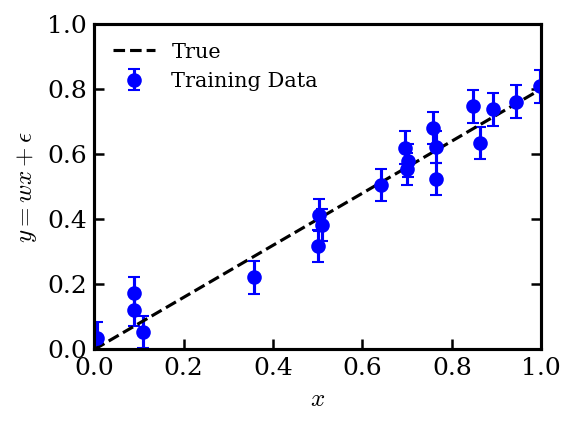

In [3]:
## generate some basic, noisy data, all in one dimension for simplicity

#Ndata = 5
Ndata = 20
sigma_noise = 0.05

np.random.seed(137)  # For reproducibility
training_input = np.random.uniform(0,1,Ndata)
training_input = np.column_stack((training_input,np.ones_like(training_input)))  # Add a column of ones for the bias term
weight_true = np.array([0.8,0.]) # true weight vector
print(training_input.shape, weight_true.shape)
training_output = np.dot(training_input, weight_true) + np.random.normal(0, sigma_noise, Ndata)  # Add Gaussian noise

## plot the training data
plt.figure(figsize=(4,3))
#plt.scatter(training_input[:,0], training_output, s=20, label='Training Data', color='b')
plt.errorbar(training_input[:,0], training_output, yerr=sigma_noise, fmt='o', label='Training Data', color='b', capsize=3)
plt.plot(np.linspace(0,1,100), weight_true[0] * np.linspace(0,1,100), 'k--', label='True')
plt.xlabel(r"$x$")
plt.ylabel(r"$y = w x + \epsilon$")
plt.xlim(0,1)
plt.ylim(0,1)
plt.legend(loc="best")
plt.tight_layout()
plt.show()


In [4]:
## Training a Gaussian Process model on the training data

kernel = DotProduct(sigma_0=1e-3)
gp_linear = GaussianProcessRegressor(kernel=kernel, alpha=1*sigma_noise**2)
gp_linear.fit(training_input, training_output)


GaussianProcessRegressor(alpha=0.0025000000000000005,
                         kernel=DotProduct(sigma_0=0.001))

**Quite note about kernels and priors**: The dot product kernel has the form $K(\vec x,\vec x') = \vec x \cdot \vec x' + \sigma_0^2$. In our case, we "cheat" and make $\vec x = (x,1)$ to incorporate the bias intrinsically, so $K(\vec x,\vec x') = x x' + 1$, setting $\sigma_0 = 0$. That that means is that our prior distribution variance looks like $K(x,x) = x^2 + 1$. At the origin, it has width 1 and away from the origin, the spread grows. This makes total sense for linear function but not necessarily for other functional forms. 

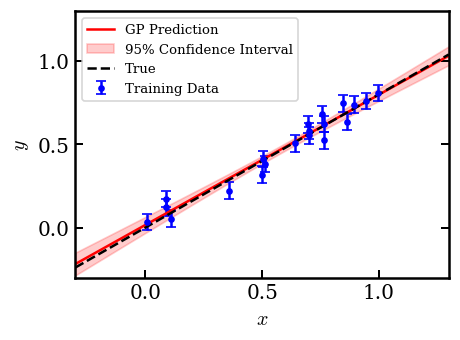

In [5]:
## Show the predictions of the GP model vs the true function and the training data
test_input = np.linspace(-0.3,1.3,100)
test_input = np.column_stack((test_input,np.ones_like(test_input)))  # Add a column of ones for the bias term
test_output_dotproduct, test_std_dotproduct = gp_linear.predict(test_input, return_std=True)

plt.figure(figsize=(4,3),dpi=120)
#plt.scatter(training_input[:,0], training_output, s=20, label='Training Data', color='b')
plt.errorbar(training_input[:,0], training_output, yerr=sigma_noise, fmt='o', label='Training Data', color='b', capsize=3, markersize=3)
plt.plot(test_input[:,0], test_output_dotproduct, 'r-', label='GP Prediction')
plt.fill_between(test_input[:,0], test_output_dotproduct - 1.96 * test_std_dotproduct, test_output_dotproduct + 1.96 * test_std_dotproduct, alpha=0.2, color='r', label='95% Confidence Interval')
plt.plot(test_input[:,0], weight_true[0] * test_input[:,0], 'k--', label='True')
plt.xlabel(r"$x$")
plt.ylabel(r"$y$")
#plt.xlim(0,1)
plt.xlim(min(test_input[:,0]),max(test_input[:,0]))
plt.ylim(min(test_input[:,0]),max(test_input[:,0]))
plt.legend(loc="best",fontsize=8, frameon=True)
plt.tight_layout()
plt.show()

**Quick note about uncertainties**: The uncertainty band we're showing (the 95% confidence interval) is describing the uncertainty in the underlying $f(x)$ prediction, not the uncertainty in observational samples. To get that uncertainty, just use add in quadrature the variances $\sigma_f^2 + \sigma^2$ where $\sigma$ is the intrinsic observational uncertainty and $\sigma_f$ is the function uncertainty (what we're plotting in this figure). 

In [6]:
## Same fitting but with a different kernel
kernel = RBF(length_scale=0.1, length_scale_bounds=(1e-2, 1e0))
gp_RBF = GaussianProcessRegressor(kernel=kernel, alpha=1*sigma_noise**2)
gp_RBF.fit(training_input, training_output)


/Users/sandipr/anaconda3/envs/pytorch/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:429: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified upper bound 1.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


GaussianProcessRegressor(alpha=0.0025000000000000005,
                         kernel=RBF(length_scale=0.1))

**Another quick note about priors**: I see you were thinking about the priors for this new kernel. Me too. In this case, the kernel is different and goes $K(\vec x, \vec x') = \exp(- |\vec x - \vec x'|^2/2\ell^2)$. So, for our scenario where $\vec x = (x,1)$, we have the following prior variance: $K(x,x) = \exp(- 0^2/2\ell^2) = 1$. So, the functional prior has a width (i.e. $\sigma_f^2$) of 1 at every $x$ location. That's fine, but if you want the functional prior to be larger than just 1, then you need to normalise the kernel accordingly. Notice also that this is not really how priors on linear functions should work. They should "grow" in width with larger $x$. 

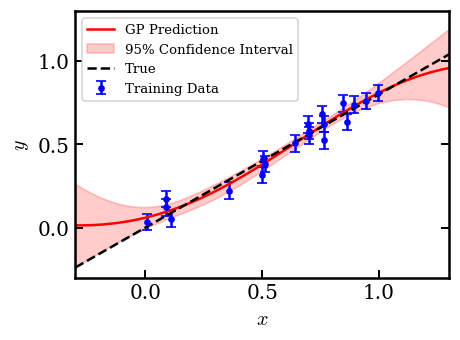

In [7]:
## Show the predictions of the GP model vs the true function and the training data
test_input = np.linspace(-0.3,1.3,100)
test_input = np.column_stack((test_input,np.ones_like(test_input)))  # Add a column of ones for the bias term
test_output_RBF, test_std_RBF = gp_RBF.predict(test_input, return_std=True)

plt.figure(figsize=(4,3),dpi=120)
#plt.scatter(training_input[:,0], training_output, s=20, label='Training Data', color='b')
plt.errorbar(training_input[:,0], training_output, yerr=sigma_noise, fmt='o', label='Training Data', color='b', capsize=3, markersize=3)
plt.plot(test_input[:,0], test_output_RBF, label='GP Prediction', color='r')
plt.fill_between(test_input[:,0], test_output_RBF - 1.96 * test_std_RBF, test_output_RBF + 1.96 * test_std_RBF, alpha=0.2, color='r', label='95% Confidence Interval')
plt.plot(test_input[:,0], weight_true[0] * test_input[:,0], 'k--', label='True')
plt.xlabel(r"$x$")
plt.ylabel(r"$y$")
plt.xlim(min(test_input[:,0]),max(test_input[:,0]))
plt.ylim(min(test_input[:,0]),max(test_input[:,0]))
plt.legend(loc="best",fontsize=8, frameon=True)
plt.tight_layout()
plt.show()

## Slightly Harder Function

Let's have some fun. Let's try a slightly more challenging function. $f(x) = x \sin(2 \pi x/ L)$. 

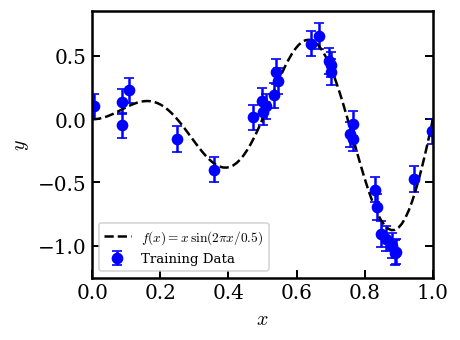

In [61]:
## generate some basic, noisy data, all in one dimension for simplicity

#Ndata = 5
Ndata = 30
sigma_noise = 0.1

def true_function(x):
    return x * np.sin(2. * np.pi * x / 0.5)

np.random.seed(137)  # For reproducibility
training_input = np.random.uniform(0,1,Ndata)[:,np.newaxis]
training_output = true_function(training_input[:,0]) + np.random.normal(0, sigma_noise, Ndata)  # Add Gaussian noise

## plot the training data
plt.figure(figsize=(4,3),dpi=120)
plt.errorbar(training_input[:,0], training_output, yerr=sigma_noise, fmt='o', label='Training Data', color='b', capsize=3)
plt.plot(np.linspace(0,1,100), true_function(np.linspace(0,1,100)), 'k--', label=r'$f(x) = x \,\sin(2 \pi x / 0.5)$')
plt.xlabel(r"$x$")
plt.ylabel(r"$y$")
plt.xlim(0,1)
#plt.ylim(0,1)
plt.legend(loc="best",fontsize=8, frameon=True)
plt.tight_layout()
plt.show()


In [62]:
## training the GP
constant_value = 1.0 # how much to scale the prior by, basically. Set to 1 for generic prior
kernel = ConstantKernel(constant_value = constant_value, constant_value_bounds = (constant_value,constant_value)) * RBF(length_scale=0.1, length_scale_bounds=(1e-2, 5e-1))
#kernel = ConstantKernel(constant_value=constant_value, constant_value_bounds=(constant_value,constant_value)) * RBF(length_scale=0.01, length_scale_bounds=(1e-2, 2e-2))   # very small kernel!
gp_RBF = GaussianProcessRegressor(kernel=kernel, alpha=1*sigma_noise**2)
gp_RBF.fit(training_input, training_output)

/Users/sandipr/anaconda3/envs/pytorch/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:419: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified lower bound 1.0. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


GaussianProcessRegressor(alpha=0.010000000000000002,
                         kernel=1**2 * RBF(length_scale=0.1))

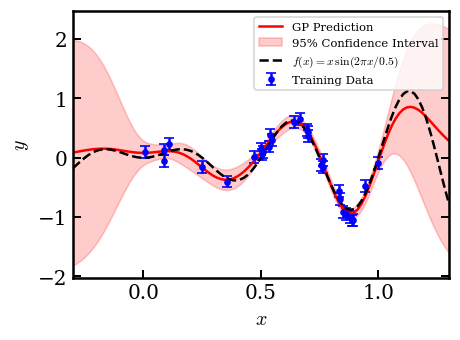

In [63]:
## Show the predictions of the GP model vs the true function and the training data
test_input = np.linspace(-0.3,1.3,100)[:,np.newaxis]
test_output_RBF, test_std_RBF = gp_RBF.predict(test_input, return_std=True)

plt.figure(figsize=(4,3),dpi=120)
#plt.scatter(training_input[:,0], training_output, s=20, label='Training Data', color='b')
plt.errorbar(training_input[:,0], training_output, yerr=sigma_noise, fmt='o', label='Training Data', color='b', capsize=3, markersize=3)
plt.plot(test_input[:,0], test_output_RBF, label='GP Prediction', color='r')
plt.fill_between(test_input[:,0], test_output_RBF - 1.96 * test_std_RBF, test_output_RBF + 1.96 * test_std_RBF, alpha=0.2, color='r', label='95% Confidence Interval')
plt.plot(test_input[:,0], true_function(test_input[:,0]), 'k--', label=r'$f(x) = x \,\sin(2 \pi x / 0.5)$')
plt.xlabel(r"$x$")
plt.ylabel(r"$y$")
plt.xlim(min(test_input[:,0]),max(test_input[:,0]))
#plt.ylim(min(test_input[:,0]),max(test_input[:,0]))
plt.legend(loc="best",fontsize=7, frameon=True)
plt.tight_layout()
plt.show()

In [64]:
## Let's show the pitfalls of the using the wrong kernel. 

## training the GP
training_input_linear = np.column_stack((training_input,np.ones_like(training_input)))  # Add a column of ones for the bias term
constant_value = 1.0 # scaling the prior. This will directly scale the prior variance.
kernel =  ConstantKernel(constant_value=constant_value,constant_value_bounds=(constant_value,constant_value)) * DotProduct(sigma_0 = 1.0e-3)
gp_linear = GaussianProcessRegressor(kernel=kernel, alpha=1*sigma_noise**2)
gp_linear.fit(training_input_linear, training_output)

/Users/sandipr/anaconda3/envs/pytorch/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:419: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified lower bound 1.0. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


GaussianProcessRegressor(alpha=0.010000000000000002,
                         kernel=1**2 * DotProduct(sigma_0=0.001))

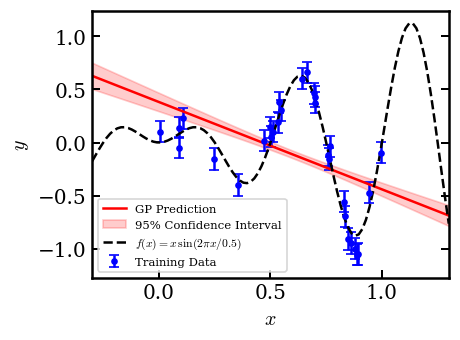

In [65]:
## Show the predictions of the GP model vs the true function and the training data
test_input = np.column_stack((np.linspace(-0.3,1.3,100), np.ones(100)))  # Add a column of ones for the bias term
test_output_linear, test_std_linear = gp_linear.predict(test_input, return_std=True)

plt.figure(figsize=(4,3),dpi=120)
#plt.scatter(training_input[:,0], training_output, s=20, label='Training Data', color='b')
plt.errorbar(training_input[:,0],training_output, yerr = sigma_noise, fmt='o', label='Training Data', color='b', capsize=3, markersize=3)
plt.plot(test_input[:,0], test_output_linear, label='GP Prediction', color='r')
plt.fill_between(test_input[:,0], test_output_linear - 1.96 * test_std_linear, test_output_linear + 1.96 * test_std_linear, alpha=0.2, color='r', label='95% Confidence Interval')
plt.plot(test_input[:,0], true_function(test_input[:,0]), 'k--', label=r'$f(x) = x \,\sin(2 \pi x / 0.5)$')
plt.xlabel(r"$x$")
plt.ylabel(r"$y$")
plt.xlim(min(test_input[:,0]),max(test_input[:,0]))
#plt.ylim(min(test_input[:,0]),max(test_input[:,0]))
plt.legend(loc="best",fontsize=7, frameon=True)
plt.tight_layout()
plt.show()